### Basic RAG

In [1]:
import sys
!{sys.executable} -m pip install langchain langchain-community langchain-openai langgraph python-dotenv langchain-text-splitters pypdf

from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.9/343.9 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


/tmp/ipykernel_979/3734924684.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


False

In [4]:
docs = (
    PyPDFLoader("./documents/book1.pdf").load() +
    PyPDFLoader("./documents/book2.pdf").load() +
    PyPDFLoader("./documents/book3.pdf").load()
)

In [5]:
len(docs)

2123

In [6]:
# 2) Chunk
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

# 3) Clean text to avoid UnicodeEncodeError (surrogates from PDF extraction)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [7]:
len(chunks)

6396

In [8]:
!pip install langchain-huggingface sentence-transformers

In [9]:
# 3) Index (fresh collection each run)
# Local execution (Requires: pip install langchain-huggingface sentence-transformers)
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/94.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [10]:
pip install faiss-gpu-cu12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.2/581.2 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 MB 9.3 MB/s eta 0:00:00


In [11]:
vector_store = FAISS.from_documents(chunks, embeddings)

In [ ]:
import os
os.environ["GROQ_API_KEY"] = "your_api_key"

In [13]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})
# 4) LLM + prompt
!pip install -q langchain-groq
from langchain_groq import ChatGroq

llm = ChatGroq(model_name="llama-3.3-70b-versatile",
temperature=0.2)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 2.0 MB/s eta 0:00:00


In [14]:
llm = ChatGroq(model_name="llama-3.3-70b-versatile",
temperature=0)

In [15]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str

In [16]:
def retrieve(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [17]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)
def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}

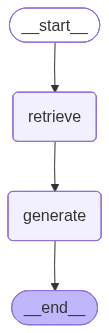

In [18]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [19]:
# 5) Run
res = app.invoke({"question": "WHat is a transformer in deep learning.", "docs": [], "answer": ""})
print(res["answer"])

which combines the steps of fit() and transform(). The transformer 
object is then used to transform the data. 

In the context of deep learning, a transformer is a type of neural network 
architecture introduced in the paper "Attention is All You Need" by 
Vaswani et al. in 2017. It is primarily designed for sequence-to-sequence 
tasks, such as machine translation, text summarization, and image 
captioning. The transformer model relies on self-attention mechanisms 
to weigh the importance of different input elements relative to each 
other. This allows the model to handle long-range dependencies and 
parallelize the computation, making it more efficient than traditional 
recurrent neural networks (RNNs) for many sequence-to-sequence tasks.

The transformer architecture consists of an encoder and a decoder. The 
encoder takes in a sequence of tokens (such as words or characters) and 
outputs a sequence of vectors. The decoder then generates the output 
sequence, one token at a time, ba

In [20]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

Custom Transformers                                                                                                64
Feature Scaling                                                                                                            65
Transformation Pipelines                                                                                          66
Select and Train a Model                                                                                               68
Training and Evaluating on the Training Set                                                         68
Better Evaluation Using Cross-Validation                                                              69
Fine-Tune Y our Model                                                                                                  71
****************************************************************************************************
CHAPTER20.DEEPGENERATIVEMODELS
20.10.2DiﬀerentiableGeneratorNets
Manygenerativemodelsa

### C-RAG

In the basic rag the retriever sometimes may retrieve some data which is not relevant to our query, due to which there is a risk of hallucination. Thus, after retrieval based on retrieved data we apply llm as filter to filter out wrong data and to include data from external sources as well. This is known as C-RAG OR Corrective RAG

In [28]:
class State(TypedDict):
    question: str
    docs: List[Document]
    strips: List[str]
    kept_strips: List[str]
    refined_context: str
    answer: str

In [29]:
def retrieve(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In C-RAG we need to make strips, thus here we make sentence level stripping

In [30]:
import re
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

We need only bool value added to make sure the thing is kept or not

In [31]:
from pydantic import BaseModel
class KeepOrDrop(BaseModel):
  keep: bool

Here, we do chaining of the filter_prompt where we need to filter the context based on relevance, after that we concat that with llm output

In [32]:
filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a relevance filter. Analyze the user's sentence "
            "against the question and determine if it should be kept."
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm

Get the question and context and then strip them into different sentences, if the llm says then relevant then keep it else remove it

In [33]:
import json

def refine(state: State)->State:
  q=state['question']
  context="\n\n".join(d.page_content for d in state["docs"]).strip()
  # decomposition
  strips=decompose_to_sentences(context)
  # filter: keep only relevant strips
  kept: List[str]=[]

  for s in strips:
    llm_output = filter_chain.invoke({"question": q, "sentence": s})
    # Modified: Checking for keywords as filter_prompt no longer requests JSON
    llm_output_text = llm_output.content.lower()
    if "keep" in llm_output_text or "true" in llm_output_text or "yes" in llm_output_text:
        is_kept = True
    else:
        is_kept = False # Default to false if no clear positive indicator

    if is_kept:
      kept.append(s)
  # RECOMPOSE: glue kept strips back together (internal knowledge)
  refined_context = "\n".join(kept).strip()

  return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

Chain the llm along with prompt and provide question along with refined_context as the total context

In [34]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": out.content}

We add a `refine` node to refine the strips we have and only provide relevant strips to the llm

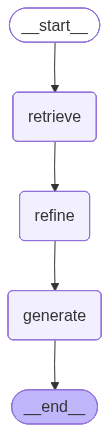

In [35]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app

Here, we use `invoke` the llm and store the relevant things in our res object and then retrieve the result

In [36]:
res = app.invoke({
    "question": "what is machine learning?",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(res["answer"])

* Machine Learning is the science (and art) of programming computers so they can learn from data. 
* For example, your spam filter is a Machine Learning program that can learn to flag.


### Retrieval Evaluator

We need to keep the document which are above certain threshold itself, else remove them or dont keep them

In [37]:
UPPER_TH = 0.7
LOWER_TH = 0.3

New we added good_docs or above the threshold ones

In [38]:
class State(TypedDict):
    question: str
    docs: List[Document]

    good_docs: List[Document] # new
    verdict: str # new
    reason: str # new

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    answer: str

We make a retrive node to retrieve the docs using a normal retrieval, the function takes the states as an i/p and then provides update state as an o/p

In [39]:
def retrieve_node(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}

Document Evaluator has 2 fields here `score` and `reason`. The score is used to score the relevance of docs, and if score high or low then the reason is also stored. This is done via changing the system prompt and then chaining with the llm o/p.
Thus, here we do the following things.

1. First of all we store the results, scores and good docs. If the results are `<0.3` we just discard them.
2. Between `0.3` to `0.7` we mark them as ambigous, else we pass them on

In [40]:
# -----------------------------
# Score-based doc evaluator
# -----------------------------
class DocEvalScore(BaseModel):
    score: float
    reason: str

doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

def eval_each_doc_node(state: State) -> State:

    q = state["question"]

    scores: List[float] = []
    reasons: List[str] = []
    good: List[Document] = []

    for d in state["docs"]:
        out = doc_eval_chain.invoke({"question": q, "chunk": d.page_content})
        scores.append(out.score)
        reasons.append(out.reason)

        # 5) for CORRECT case we will refine only docs with score > LOWER_TH
        if out.score > LOWER_TH:
            good.append(d)

    # 2) CORRECT if at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }

    # 3) INCORRECT if all docs < LOWER_TH
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        why = "No chunk was sufficient."
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}. {why}",
        }

    # 4) Anything in between => AMBIGUOUS
    why = "Mixed relevance signals."
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. {why}",
    }

Here, we do the following things.
1. First we decompose sentences to strips
2. Then we pass them to llm and ask it add `keep` if the strips are relevant
3. For that purpose we use a boolean var keep.
4. We chain it with the llm o/p

-> Recomposition

5. After that, we get the context and then strip them into sentences
6. After that, we check if keep was added by llm
7. If yes, then we add it to refined context
8. At last we return the updated state variable

In [41]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return JSON with a single key 'keep'. "
            "The value of 'keep' must be a JSON boolean (true or false), not a string. "
            "Set 'keep' to true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

# -----------------------------
# REFINING (Decompose -> Filter -> Recompose)
# -----------------------------
def refine(state: State) -> State:
    q = state["question"]

    # Combine retrieved docs into one context string
    # 5) In CORRECT case, eval node populates good_docs with docs having score > LOWER_TH
    context = "\n\n".join(d.page_content for d in state["good_docs"]).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

Finally, we create the main system prompt and after that we create the respective graph nodes of our langraph workflow.
1. First we generate the response via providing the refined context and the question to the llm
2. Then, we create a fail node that if none of the docs pass then we just route to end node
3. We have the ambigous node as discussed above
4. Then we also added a routing node, which routes as done below.

-> Workflow

      5. After starting node, we retrieve the docs
      6. then we evaluate the docs and refine the context
      7. then we route as done below, special case if dont get any proper docs then we web search via tavily
      8. At last, we make edges to the END node

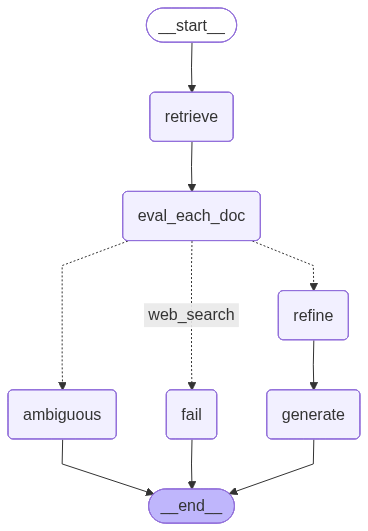

In [42]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke(
        {"question": state["question"], "refined_context": state["refined_context"]}
    )
    return {"answer": out.content}
def fail_node(state: State) -> State:
    return {"answer": f"FAIL: {state['reason']}"}

def ambiguous_node(state: State) -> State:
    return {"answer": f"Ambiguous: {state['reason']}"}

def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    elif state["verdict"] == "INCORRECT":
        return "web_search"
    else:
        return "ambiguous"
g = StateGraph(State)
g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)
g.add_node("refine", refine)
g.add_node("generate", generate)
g.add_node("fail", fail_node)
g.add_node("ambiguous", ambiguous_node)


g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {"refine": "refine", "web_search": "fail", "ambiguous": "ambiguous"}
)
g.add_edge("refine", "generate")
g.add_edge("generate", END)
g.add_edge("fail", END)

app = g.compile()
app

In [43]:
res = app.invoke(
    {
        "question": "What are attention mechanisms and why are they important in current models?",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: CORRECT
REASON: At least one retrieved chunk scored > 0.7.

OUTPUT:
 Attention mechanisms are inspired by the way humans focus on specific parts of a scene through saccadic eye movements, allowing them to glimpse the most visually salient or task-relevant parts. In deep learning, attention mechanisms have been particularly successful in natural language processing, enabling models to focus on specific parts of the input data that are relevant to the task at hand. They are important because they allow models to selectively concentrate on certain aspects of the input, mimicking the way humans process information, and have shown promise in improving model performance.


### Web Search Refinement

In [44]:
class State(TypedDict):

    question: str
    docs: List[Document]

    good_docs: List[Document]
    verdict: str
    reason: str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    web_docs: List[Document] # new

    answer: str

We use `Tavily` for searching via web, thus for that we download the needed dependencies and then we set the api_key

In [45]:
from langchain_community.tools.tavily_search import TavilySearchResults

In [46]:
os.environ['TAVILY_API_KEY']="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"

In [47]:
import json

# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return JSON with a single key 'keep'. "
            "The value of 'keep' must be a JSON boolean (true or false), not a string. "
            "Set 'keep' to true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

# Removed .with_structured_output for manual parsing
filter_chain = filter_prompt | llm

# -----------------------------
# REFINING (Decompose -> Filter -> Recompose)
# -----------------------------
def refine(state: State) -> State:
    q = state["question"]

    if state.get("verdict") == "CORRECT":
        context = "\n\n".join(d.page_content for d in state["good_docs"]).strip()
    else:
        context = "\n\n".join(d.page_content for d in state["web_docs"]).strip()

    strips = decompose_to_sentences(context)

    kept: List[str] = []
    for s in strips:
        llm_output_str = filter_chain.invoke({"question": q, "sentence": s}).content
        try:
            # Manually parse the JSON output and convert 'keep' to boolean
            llm_output_json = json.loads(llm_output_str)
            # Ensure that if the LLM returns 'true' or 'false' as a string, it's converted to a Python boolean
            is_kept = str(llm_output_json.get("keep", "false")).lower() == "true" # Default to false if 'keep' is missing or not a valid boolean string
        except json.JSONDecodeError:
            # Handle cases where LLM doesn't return valid JSON
            is_kept = False # Default to False if JSON parsing fails
            # You might want to log this for debugging purposes to see malformed JSON outputs

        if is_kept:
            kept.append(s)

    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }

Rest all of implementation is same, except the new web search refinement node that we have here

In [48]:
# -----------------------------
# Web search (Iteration 4)
# Assumption: web search does not fail (no fail node in this branch)
# -----------------------------
tavily = TavilySearchResults(max_results=5)

def web_search_node(state: State) -> State:

    q = state["question"]  # no query rewrite
    results = tavily.invoke({"query": q})  # no knowledge selection

    web_docs = []
    for r in results or []:

        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")

        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"

        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title}))

    return {"web_docs": web_docs}

/tmp/ipykernel_979/39063620.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=5)


In [49]:
def ambiguous_node(state: State) -> State:
    return {"answer": f"Ambiguous: {state['reason']}"}

def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    elif state["verdict"] == "INCORRECT":
        return "web_search"
    else:
        return "ambiguous"

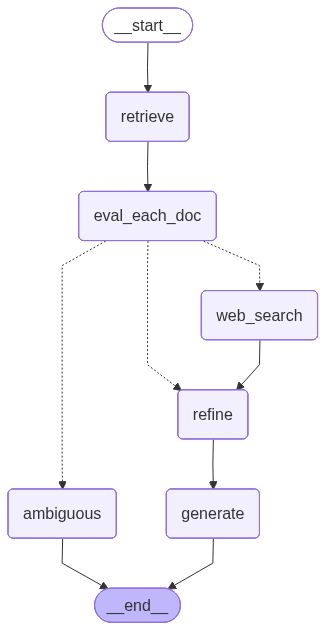

In [50]:
# -----------------------------
# Graph
# -----------------------------
g = StateGraph(State)

g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)
g.add_node("web_search", web_search_node)
g.add_node("refine", refine)          # uses verdict to pick good_docs vs web_docs
g.add_node("generate", generate)
g.add_node("ambiguous", ambiguous_node)

# flow
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

# route after evaluation
g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "refine": "refine",          # CORRECT -> refine (good_docs)
        "web_search": "web_search",  # INCORRECT -> web_search
        "ambiguous": "ambiguous",    # AMBIGUOUS -> end (your current choice)
    },
)

# ✅ key change: web_search now goes through refine
g.add_edge("web_search", "refine")    # INCORRECT -> refine (web_docs)
g.add_edge("refine", "generate")      # CORRECT/INCORRECT -> generate

g.add_edge("generate", END)
g.add_edge("ambiguous", END)

app = g.compile()
app

In [51]:
res = app.invoke(
    {
        "question": "AI news from the last month",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_docs": [],   # ✅ added
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])
print(res["web_docs"])

VERDICT: INCORRECT
REASON: All retrieved chunks scored < 0.3. No chunk was sufficient.

OUTPUT:
 Here are some AI news from the last month: 

1. AI leadership volatility: OpenAI, Google, and Anthropic have each taken turns leading across benchmarks, enterprise revenue, and investor attention.
2. China blocks Meta acquisition of AI startup Manus amid geopolitical tensions.
3. AI coding agent failure: A startup lost its production database and backups after an AI coding agent executed a destructive command.
4. Uber caps employee AI spending after blowing through budget in 4 months.
5. Microsoft launches Scout, an OpenClaw-inspired personal assistant.
6. Google rolls out fake call detection to protect against AI deepfake impersonation scams.
7. Alphabet plans to raise $80B to pay for AI buildout.
8. Nvidia chases $200B CPU market with AI agent PCs.
9. Florida sues OpenAI, Sam Altman, in first-of-its-kind lawsuit over violent incidents.
10. Anthropic files to go public.
11. DuckDuckGo make

### Query Rewriting

in query rewriting, sometimes users give generic queries which dont give good results from the net, thus we refine the query and then move on

In [52]:
class State(TypedDict):

    question: str
    docs: List[Document]

    good_docs: List[Document]
    verdict: str
    reason: str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    web_docs: List[Document]

    web_query: str          # ✅ NEW

    answer: str

This is the new web query model where we add the query, and then we rewrite the prompt and then chain the model respectively. When invoked it refines the query

In [53]:
class WebQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency (e.g., recent/latest/last week/last month), add a constraint like (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)

def rewrite_query_node(state: State) -> State:
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}


In [56]:
tavily = TavilySearchResults(max_results=5)

def web_search_node(state: State) -> State:
    q = state.get("web_query") or state["question"]   # ✅ fallback if empty
    results = tavily.invoke({"query": q})

    web_docs = []
    for r in results or []:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"
        web_docs.append(Document(page_content=text, metadata={"url": url, "title": title}))

    return {"web_docs": web_docs}

In [59]:
def ambiguous_node(state: State) -> State:
    return {"answer": f"Ambiguous: {state['reason']}"}

def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    elif state["verdict"] == "INCORRECT":
        return "rewrite_query"   # ✅ changed
    else:
        return "ambiguous"

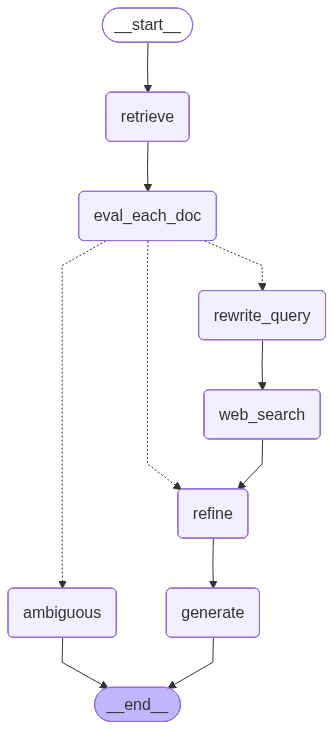

In [60]:
g = StateGraph(State)

g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)

g.add_node("rewrite_query", rewrite_query_node)  # ✅ NEW
g.add_node("web_search", web_search_node)

g.add_node("refine", refine)
g.add_node("generate", generate)
g.add_node("ambiguous", ambiguous_node)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "refine": "refine",
        "rewrite_query": "rewrite_query",  # ✅ NEW branch
        "ambiguous": "ambiguous",
    },
)

# INCORRECT path: rewrite -> web_search -> refine -> generate
g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "refine")
g.add_edge("refine", "generate")

g.add_edge("generate", END)
g.add_edge("ambiguous", END)

app = g.compile()

app

In [61]:
res = app.invoke(
    {
        "question": "Recent AI news",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_docs": [],   # ✅ added
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: INCORRECT
REASON: All retrieved chunks scored < 0.3. No chunk was sufficient.

OUTPUT:
 Recent AI news includes:

1. Google's AI announcements from April 2026, with over 260 announcements to help businesses grow in the new agentic era.
2. AMD pioneering AI innovation with 2nm EPYC processors.
3. Microsoft's Majorana 2 quantum chip being used as a case study for agentic AI in R&D.
4. US and Japan announcing a sweeping AI and tech collaboration.
5. Google folding Display Ads into its AI-first Demand Gen platform.
6. Anthropic releasing Claude Opus 4.8 and receiving $65 billion in funding at a $900 billion valuation.
7. NVIDIA chasing the $200B CPU market with AI agent PCs from Microsoft, Dell, and HP.
8. OpenAI being sued by Florida in a first-of-its-kind lawsuit over violent incidents.
9. Anthropic filing to go public.
10. AI weather startups out-forecasting government agencies.

These are just a few examples of the latest AI news and developments from March to May 2026.


### Ambiguous Node

In [62]:
# -----------------------------
# Routing
# CORRECT => refine
# INCORRECT / AMBIGUOUS => rewrite -> web_search -> refine -> generate
# -----------------------------
def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    else:
        return "rewrite_query"

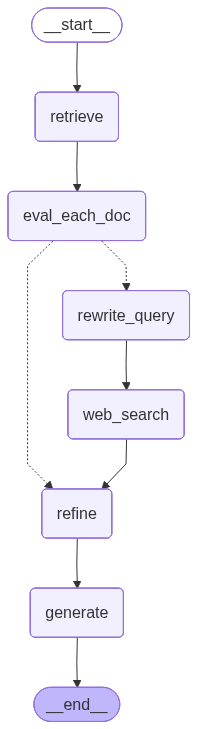

In [63]:
# -----------------------------
# Build graph
# -----------------------------
g = StateGraph(State)

g.add_node("retrieve", retrieve_node)
g.add_node("eval_each_doc", eval_each_doc_node)

g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)

g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "eval_each_doc")

g.add_conditional_edges(
    "eval_each_doc",
    route_after_eval,
    {
        "refine": "refine",
        "rewrite_query": "rewrite_query",
    },
)

# non-correct path
g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "refine")

# correct path already goes to refine
g.add_edge("refine", "generate")
g.add_edge("generate", END)

app = g.compile()

app

In [64]:
# -----------------------------
# Run example
# -----------------------------
res = app.invoke(
    {
        "question": "Batch normalization vs layer normalization",
        "docs": [],
        "good_docs": [],
        "verdict": "",
        "reason": "",
        "strips": [],
        "kept_strips": [],
        "refined_context": "",
        "web_query": "",
        "web_docs": [],
        "answer": "",
    }
)

print("VERDICT:", res["verdict"])
print("REASON:", res["reason"])
print("WEB_QUERY:", res["web_query"])
print("\nOUTPUT:\n", res["answer"])

VERDICT: AMBIGUOUS
REASON: No chunk scored > 0.7, but not all were < 0.3. Mixed relevance signals.
WEB_QUERY: batch normalization vs layer normalization

OUTPUT:
 Batch normalization and layer normalization are two different techniques used to normalize the inputs to a neural network. 

Batch normalization splits large data sets into smaller batches and adjusts the mean and variance of each batch. It computes the mean and variance across the batch and applies the same normalization to all examples in the batch.

Layer normalization, on the other hand, applies the same computation to one sequence at a time. It normalizes the inputs across the features for each individual data point, rather than across the batch. This means that the statistics (mean and variance) are computed across each feature and are independent of other examples.

The key differences between batch normalization and layer normalization are:

1. **Batch size**: Batch normalization relies on batches, while layer normali